![clothing_classification](figures/clothing_classification.png)

### Project Goal

As a data scientist for the new e-commerce retailer, Fashion Forward, I have been tasked with developing a robust garment classifier. The primary objective is to build a deep learning model that accurately categorizes product images into 10 distinct classes (e.g., T-shirt, Trouser, Coat). This automated system is critical for streamlining the product listing process, enhancing customer search experience, and improving inventory management.

### My Approach

To solve this problem, I will follow a structured data science workflow:

1.  **Data Exploration and Preparation**: I will start by performing an Exploratory Data Analysis (EDA) on the FashionMNIST dataset to understand its characteristics and prepare it for modeling. This includes creating a validation set to properly evaluate model performance during training.
2.  **Baseline Model**: I will define and train a simple Convolutional Neural Network (CNN) as a baseline to establish an initial performance benchmark.
3.  **Iterative Improvement**: I will systematically improve upon the baseline by conducting experiments, such as increasing training duration and deepening the network architecture. I will track training and validation metrics to diagnose model behavior.
4.  **Final Evaluation**: I will select the best-performing model and conduct a final, comprehensive evaluation on the held-out test set. This will include generating a confusion matrix to analyze class-specific performance and identify common misclassifications.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# Import functions from our refactored scripts
from src.data_loader import get_data_loaders
from src.model import BaselineCNN, DeeperCNN
from src.train import train_and_validate, plot_history
from src.evaluate import evaluate_model

# Set the style for the plots
sns.set(style="whitegrid")

In [2]:
import random
import numpy as np

# For reproducibility
def set_seed(seed):
    """Set seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    np.random.seed(seed)  # Numpy module.
    random.seed(seed)  # Python random module.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(42)

In [3]:
# Load the data using the refactored function
train_loader, val_loader, test_loader, classes = get_data_loaders(batch_size=64)
num_classes = len(classes)

# To get the full dataset for EDA, we can access it from one of the loaders
full_train_data = train_loader.dataset.dataset

print(f"Classes: {classes}")
print(f"Number of classes: {num_classes}")

Number of training examples: 48000
Number of validation examples: 12000
Number of testing examples: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Number of classes: 10


### Exploratory Data Analysis

Before building the model, I will perform an Exploratory Data Analysis (EDA) to understand the dataset's characteristics. This involves checking the class distribution to ensure it is balanced and visualizing sample images to get a qualitative sense of the classification task.

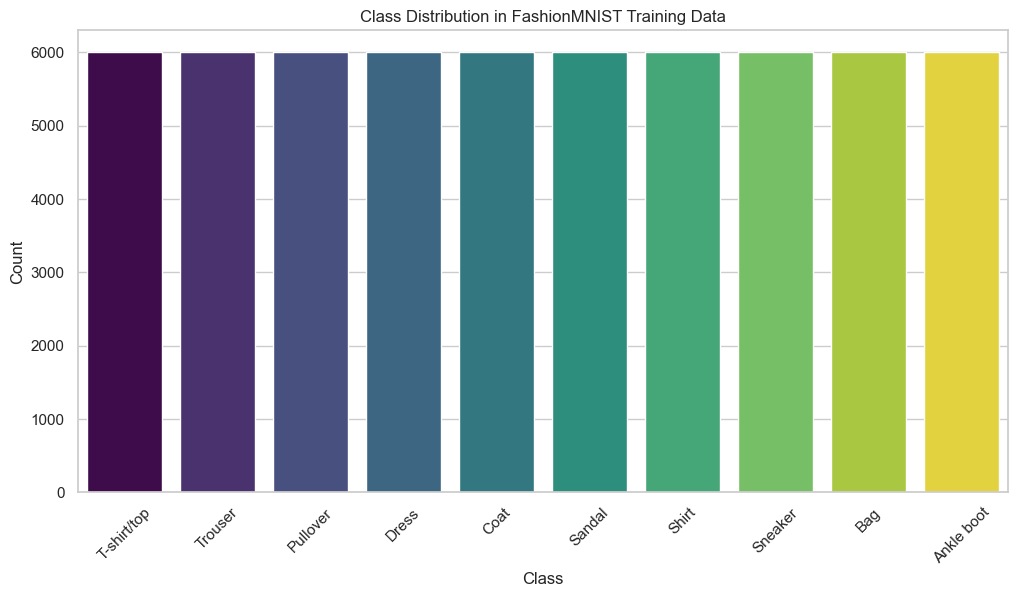

In [4]:
# Visualize class distribution
plt.figure(figsize=(12, 6))
# We use the targets from the full training dataset to get the overall distribution
sns.countplot(x=full_train_data.targets, hue=full_train_data.targets, palette="viridis", legend=False)
plt.title('Class Distribution in FashionMNIST Training Data')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=range(num_classes), labels=classes, rotation=45)
plt.savefig('./figures/class_distribution.png')
plt.show()

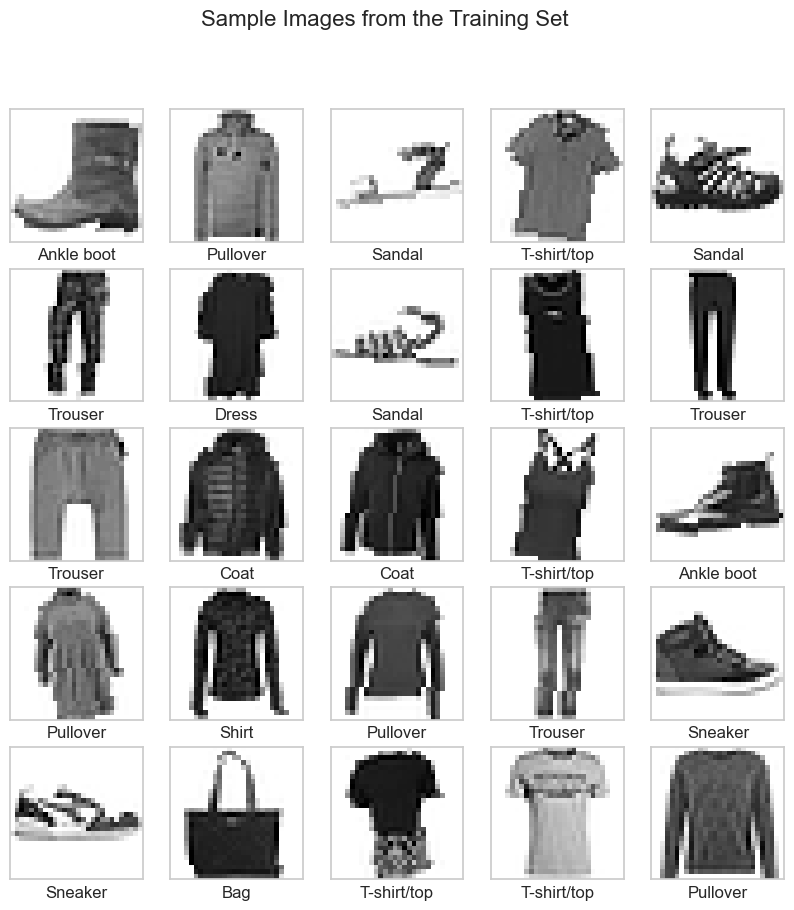

In [5]:
# Display sample images from the training set
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # Accessing data from a Subset requires .dataset (the original dataset) and .indices
    image, label_index = train_loader.dataset.dataset[train_loader.dataset.indices[i]]
    plt.imshow(image.squeeze(), cmap=plt.cm.binary)
    plt.xlabel(classes[label_index])
plt.suptitle('Sample Images from the Training Set', fontsize=16)
plt.show()

### Experiment 1: Baseline CNN Model

I will begin by training the simple, single-layer `BaselineCNN` for a limited number of epochs. This will provide a performance baseline and allow me to verify that the training pipeline is working correctly. I selected `Adam` as the optimizer and `CrossEntropyLoss` as the criterion, which are standard and effective choices for this type of multi-class classification problem.

Training Baseline CNN...
Epoch 1/5 | Train Loss: 0.6027, Train Acc: 0.7942 | Val Loss: 0.4694, Val Acc: 0.8274
Epoch 1/5 | Train Loss: 0.6027, Train Acc: 0.7942 | Val Loss: 0.4694, Val Acc: 0.8274
Epoch 2/5 | Train Loss: 0.4300, Train Acc: 0.8486 | Val Loss: 0.3920, Val Acc: 0.8655
Epoch 2/5 | Train Loss: 0.4300, Train Acc: 0.8486 | Val Loss: 0.3920, Val Acc: 0.8655
Epoch 3/5 | Train Loss: 0.3929, Train Acc: 0.8614 | Val Loss: 0.3704, Val Acc: 0.8692
Epoch 3/5 | Train Loss: 0.3929, Train Acc: 0.8614 | Val Loss: 0.3704, Val Acc: 0.8692
Epoch 4/5 | Train Loss: 0.3698, Train Acc: 0.8686 | Val Loss: 0.3600, Val Acc: 0.8742
Epoch 4/5 | Train Loss: 0.3698, Train Acc: 0.8686 | Val Loss: 0.3600, Val Acc: 0.8742
Epoch 5/5 | Train Loss: 0.3547, Train Acc: 0.8741 | Val Loss: 0.3484, Val Acc: 0.8798
Epoch 5/5 | Train Loss: 0.3547, Train Acc: 0.8741 | Val Loss: 0.3484, Val Acc: 0.8798


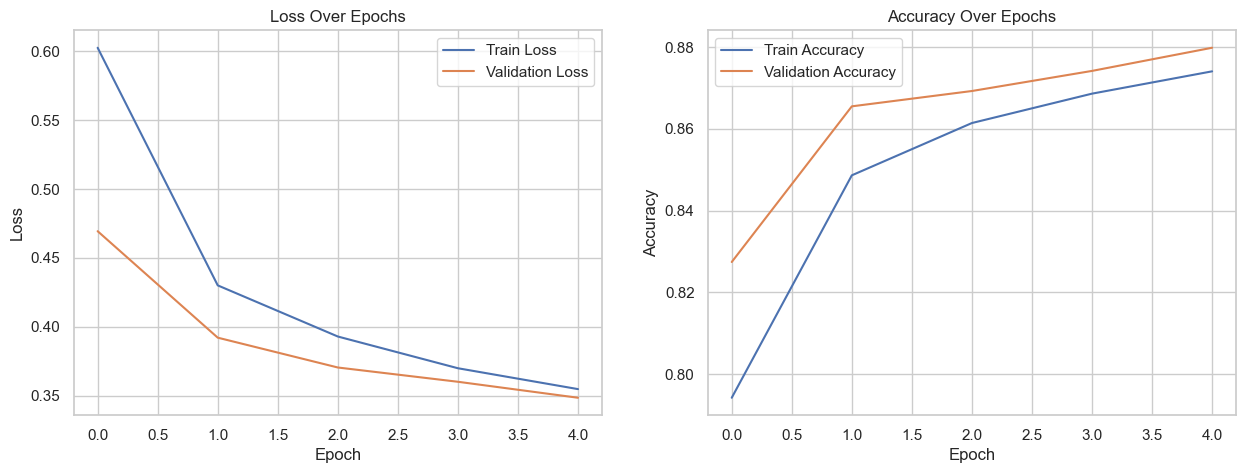

In [6]:
# Instantiate the baseline model, optimizer, and loss function
baseline_model = BaselineCNN(num_classes=num_classes)
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train for 5 epochs
print("Training Baseline CNN...")
baseline_history = train_and_validate(
    model=baseline_model,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=5,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes
)

# Plot the results
plot_history(baseline_history)

### Experiment 2: Training for More Epochs

The baseline model's validation accuracy was still trending upward after 5 epochs, suggesting it was under-trained. For my next experiment, I will continue training the same `BaselineCNN` architecture but for a total of 15 epochs to see if performance improves with more training time.

Training Baseline CNN for 15 epochs...
Epoch 1/15 | Train Loss: 0.6037, Train Acc: 0.7896 | Val Loss: 0.4285, Val Acc: 0.8498
Epoch 1/15 | Train Loss: 0.6037, Train Acc: 0.7896 | Val Loss: 0.4285, Val Acc: 0.8498
Epoch 2/15 | Train Loss: 0.4189, Train Acc: 0.8543 | Val Loss: 0.3845, Val Acc: 0.8671
Epoch 2/15 | Train Loss: 0.4189, Train Acc: 0.8543 | Val Loss: 0.3845, Val Acc: 0.8671
Epoch 3/15 | Train Loss: 0.3815, Train Acc: 0.8660 | Val Loss: 0.3626, Val Acc: 0.8728
Epoch 3/15 | Train Loss: 0.3815, Train Acc: 0.8660 | Val Loss: 0.3626, Val Acc: 0.8728
Epoch 4/15 | Train Loss: 0.3595, Train Acc: 0.8731 | Val Loss: 0.3460, Val Acc: 0.8797
Epoch 4/15 | Train Loss: 0.3595, Train Acc: 0.8731 | Val Loss: 0.3460, Val Acc: 0.8797
Epoch 5/15 | Train Loss: 0.3443, Train Acc: 0.8792 | Val Loss: 0.3346, Val Acc: 0.8829
Epoch 5/15 | Train Loss: 0.3443, Train Acc: 0.8792 | Val Loss: 0.3346, Val Acc: 0.8829
Epoch 6/15 | Train Loss: 0.3340, Train Acc: 0.8820 | Val Loss: 0.3322, Val Acc: 0.8851
Epoc

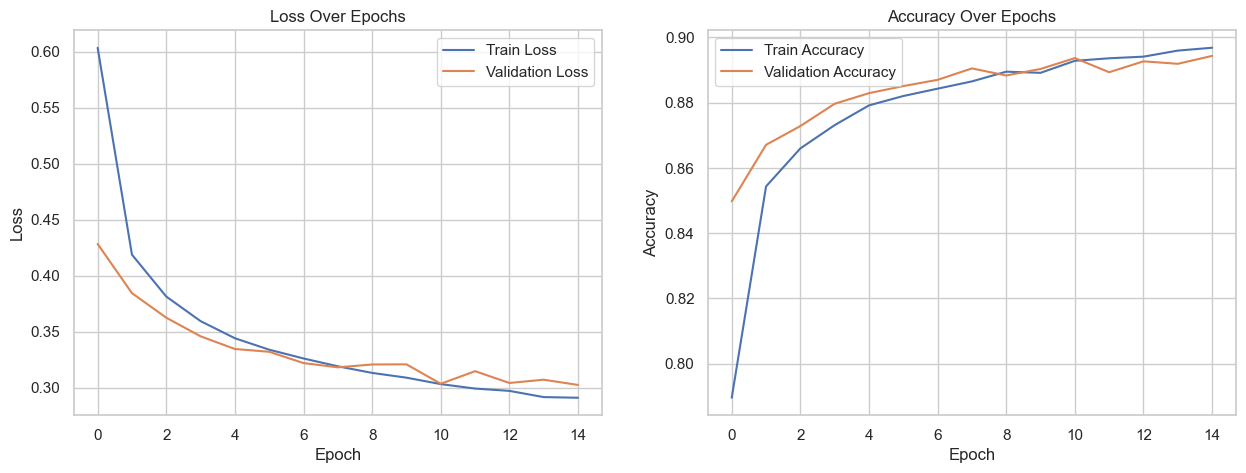

In [7]:
# Instantiate a new baseline model to train for longer
long_train_model = BaselineCNN(num_classes=num_classes)
optimizer = optim.Adam(long_train_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train for 15 epochs
print("Training Baseline CNN for 15 epochs...")
long_train_history = train_and_validate(
    model=long_train_model,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes
)

# Plot the results
plot_history(long_train_history)

### Experiment 3: Using a Deeper Network

While training for more epochs improved performance, the validation accuracy began to plateau, indicating the simple model may have reached its capacity. To capture more complex features from the images, I will now train the `DeeperCNN` model, which includes a second convolutional and pooling layer. I will train it for 15 epochs, as this duration proved effective in the previous experiment.

Training Deeper CNN...
Epoch 1/15 | Train Loss: 0.7359, Train Acc: 0.7323 | Val Loss: 0.4804, Val Acc: 0.8251
Epoch 1/15 | Train Loss: 0.7359, Train Acc: 0.7323 | Val Loss: 0.4804, Val Acc: 0.8251
Epoch 2/15 | Train Loss: 0.5014, Train Acc: 0.8191 | Val Loss: 0.3820, Val Acc: 0.8578
Epoch 2/15 | Train Loss: 0.5014, Train Acc: 0.8191 | Val Loss: 0.3820, Val Acc: 0.8578
Epoch 3/15 | Train Loss: 0.4471, Train Acc: 0.8387 | Val Loss: 0.3535, Val Acc: 0.8704
Epoch 3/15 | Train Loss: 0.4471, Train Acc: 0.8387 | Val Loss: 0.3535, Val Acc: 0.8704
Epoch 4/15 | Train Loss: 0.4107, Train Acc: 0.8510 | Val Loss: 0.3279, Val Acc: 0.8802
Epoch 4/15 | Train Loss: 0.4107, Train Acc: 0.8510 | Val Loss: 0.3279, Val Acc: 0.8802
Epoch 5/15 | Train Loss: 0.3872, Train Acc: 0.8597 | Val Loss: 0.3115, Val Acc: 0.8845
Epoch 5/15 | Train Loss: 0.3872, Train Acc: 0.8597 | Val Loss: 0.3115, Val Acc: 0.8845
Epoch 6/15 | Train Loss: 0.3710, Train Acc: 0.8661 | Val Loss: 0.2952, Val Acc: 0.8896
Epoch 6/15 | Train L

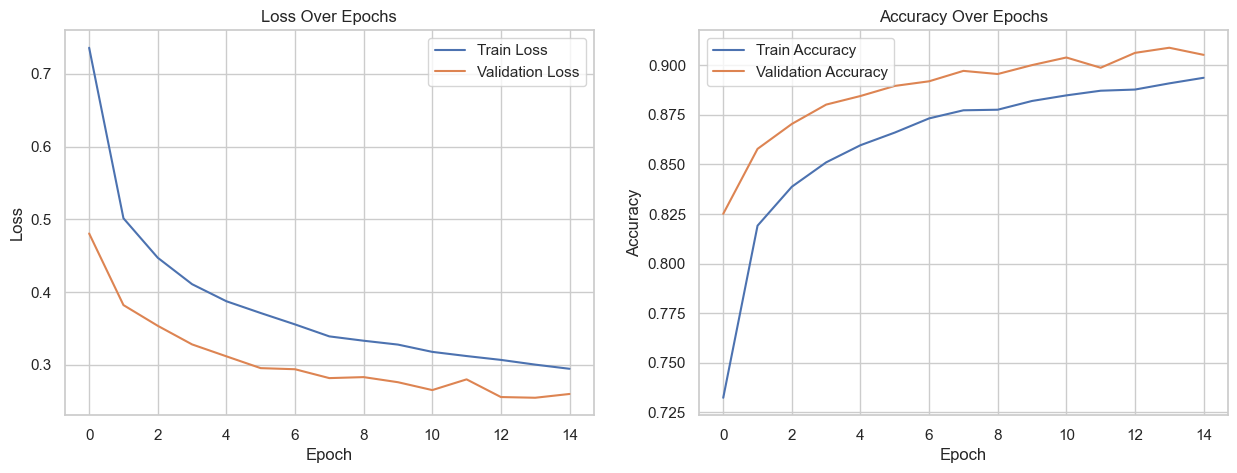

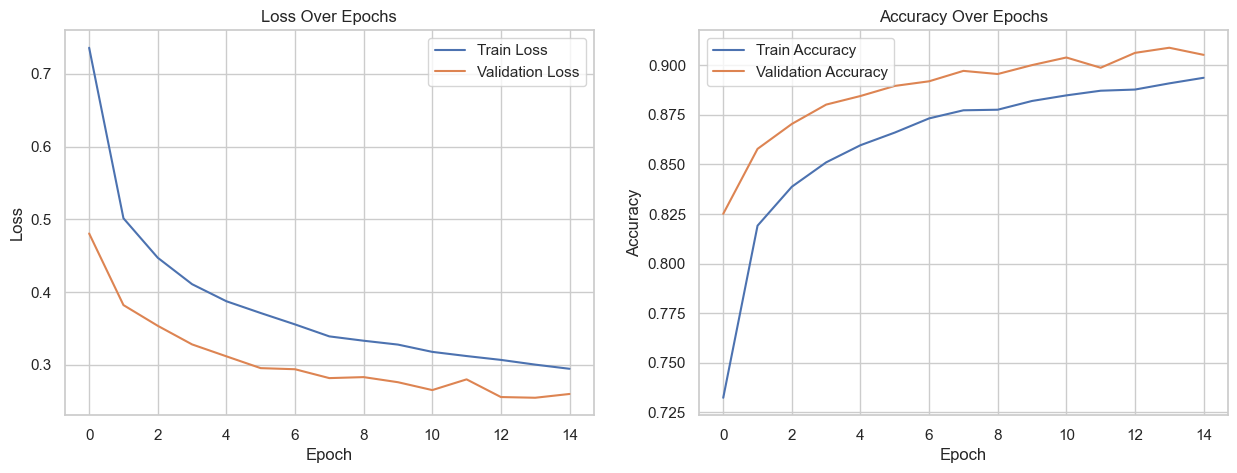

In [8]:
# Instantiate the deeper model
deeper_model = DeeperCNN(num_classes=num_classes)
optimizer = optim.Adam(deeper_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train for 15 epochs
print("Training Deeper CNN...")
deeper_history = train_and_validate(
    model=deeper_model,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes
)

# Plot the results
plot_history(deeper_history)
# Save the training history plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(deeper_history['train_loss'], label='Train Loss')
ax1.plot(deeper_history['val_loss'], label='Validation Loss')
ax1.set_title('Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax2.plot(deeper_history['train_acc'], label='Train Accuracy')
ax2.plot(deeper_history['val_acc'], label='Validation Accuracy')
ax2.set_title('Accuracy Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
plt.savefig('./figures/training_history.png')
plt.show()

### Final Model Evaluation

The `DeeperCNN` trained for 15 epochs achieved the highest and most stable validation accuracy. I have selected this as the final model. Now, I will perform a definitive evaluation on the held-out test set, which the model has not seen before. This will provide an unbiased assessment of its real-world performance.

The evaluation will include:
-   Overall test accuracy.
-   Per-class precision and recall to understand its strengths and weaknesses.
-   A confusion matrix to visualize misclassifications.

# Evaluate the best model on the test set


Evaluating final model on the test set...
Overall Test Accuracy: 0.9003

Per-Class Precision and Recall:
T-shirt/top : Precision=0.8074, Recall=0.8970
Trouser     : Precision=0.9939, Recall=0.9780
Pullover    : Precision=0.8438, Recall=0.8590
Dress       : Precision=0.8910, Recall=0.9070
Coat        : Precision=0.8199, Recall=0.8830
Sandal      : Precision=0.9937, Recall=0.9400
Shirt       : Precision=0.7925, Recall=0.6300
Sneaker     : Precision=0.9106, Recall=0.9880
Bag         : Precision=0.9859, Recall=0.9760
Ankle boot  : Precision=0.9682, Recall=0.9450
Overall Test Accuracy: 0.9003

Per-Class Precision and Recall:
T-shirt/top : Precision=0.8074, Recall=0.8970
Trouser     : Precision=0.9939, Recall=0.9780
Pullover    : Precision=0.8438, Recall=0.8590
Dress       : Precision=0.8910, Recall=0.9070
Coat        : Precision=0.8199, Recall=0.8830
Sandal      : Precision=0.9937, Recall=0.9400
Shirt       : Precision=0.7925, Recall=0.6300
Sneaker     : Precision=0.9106, Recall=0.9880
Bag 

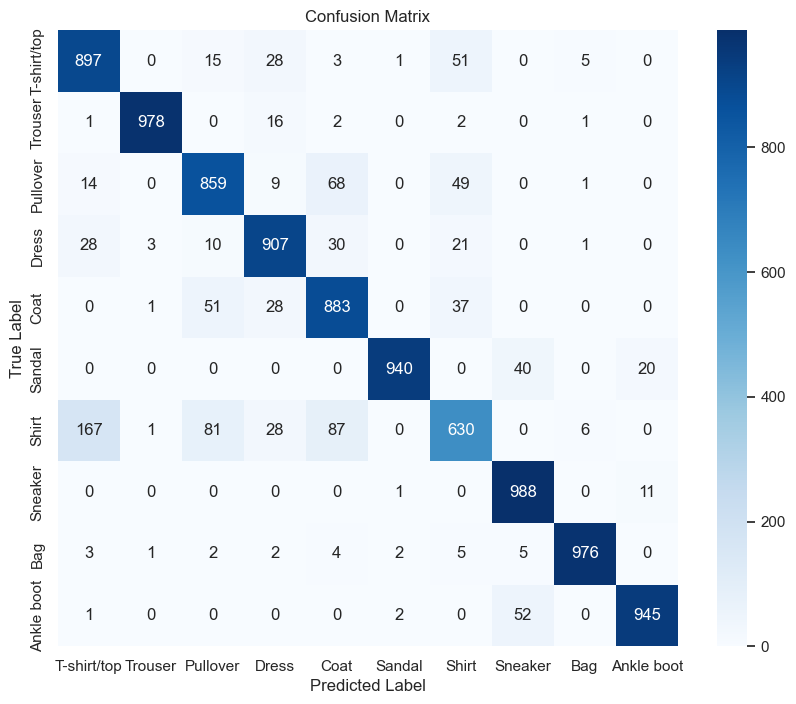

In [9]:
from sklearn.metrics import confusion_matrix

print("Evaluating final model on the test set...")
accuracy, precision, recall, all_labels, all_preds = evaluate_model(deeper_model, test_loader, classes)

# Save the confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('./figures/confusion_matrix.png')
plt.show()

In [10]:
# Save the model state dictionary
model_save_path = "fashion_mnist_cnn.pth"
torch.save(deeper_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to fashion_mnist_cnn.pth


### Save the Final Model

To make the model usable for future inference without retraining, I will save its learned parameters (the `state_dict`) to a file. This is a crucial step for deploying the model into a production environment.